<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/TEST1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hierarcal Clusstering , Preprocessing , Data visualization , Confusion matrix and accuracy


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [6]:
df = pd.read_csv("Mall_Customers.csv")

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [10]:
X = df.drop("CustomerID", axis=1)

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

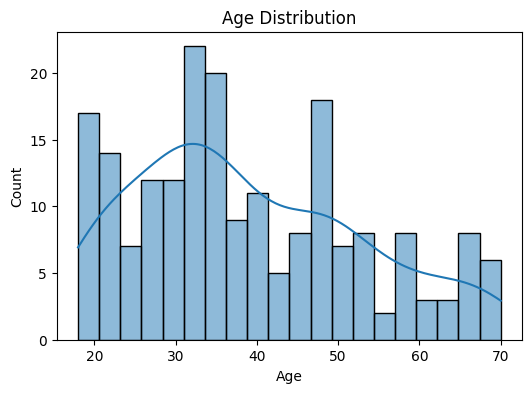

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

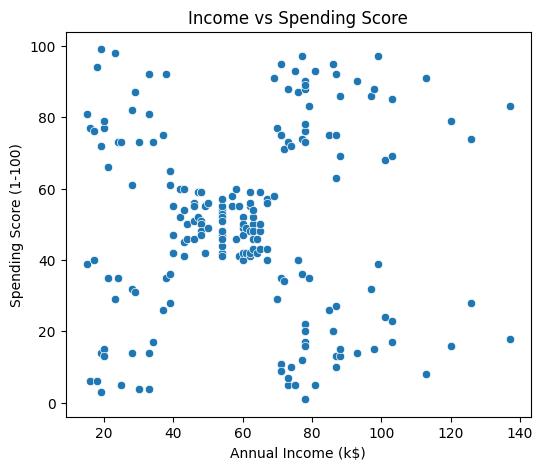

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'])
plt.title("Income vs Spending Score")
plt.show()

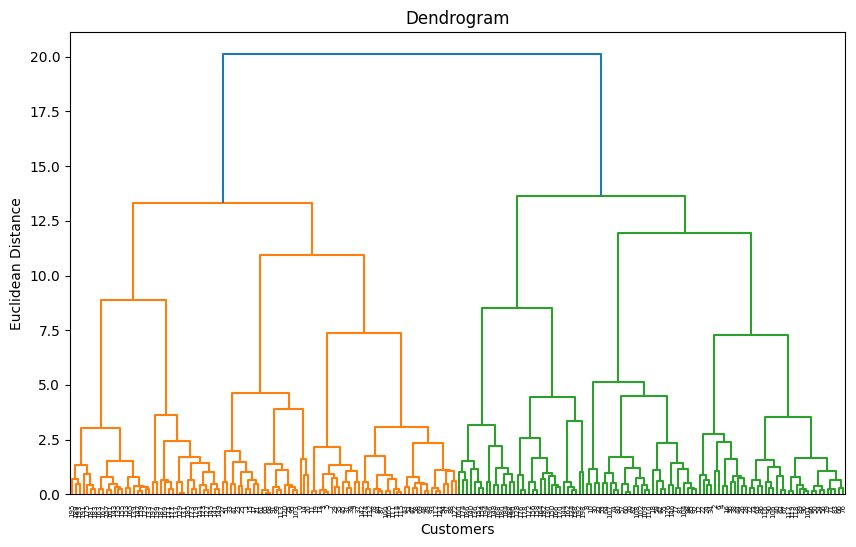

In [16]:
plt.figure(figsize=(10,6))

linkage_matrix = linkage(X_scaled, method='ward')

dendrogram(linkage_matrix)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [17]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')

clusters = model.fit_predict(X_scaled)

df['Cluster'] = clusters

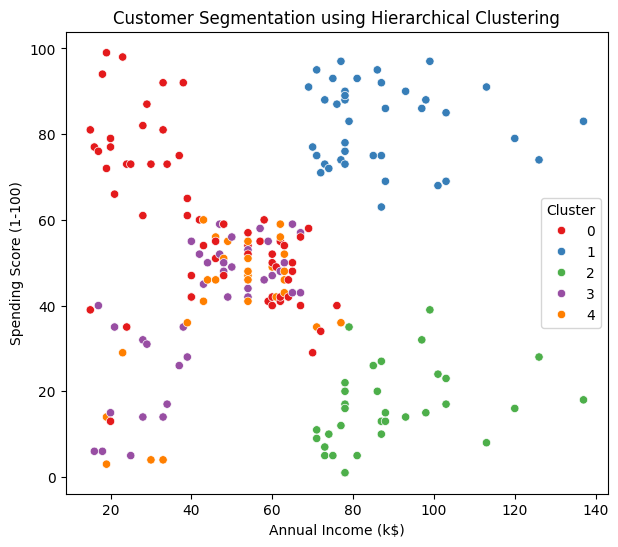

In [18]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation using Hierarchical Clustering")
plt.show()

In [19]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.28699413201651747


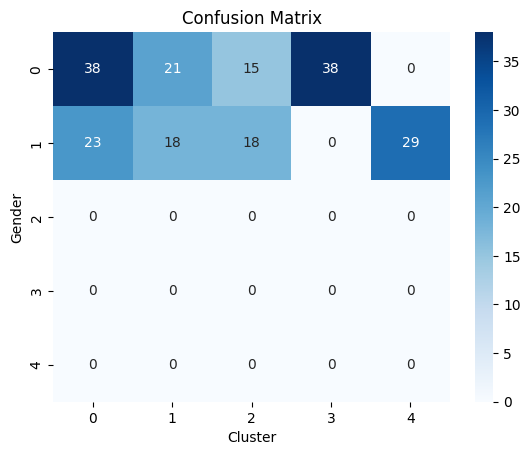

In [23]:
cm = confusion_matrix(df['Gender'], df['Cluster'])

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Cluster")
plt.ylabel("Gender")
plt.show()